## Load Your Single Cell or Spatial Data & set up experiment directory
we will use all codex datasets for this example:
1. upmc
2. charville
3. dfci

In [9]:
from tic.data.loader import load_codex_upmc
example_adata = load_codex_upmc()
print(example_adata)

AnnData object with n_obs × n_vars = 4360 × 22
    obs: 'cell_id', 'cell_type', 'size'
    uns: 'tissue_id', 'data_level'
    obsm: 'spatial'


/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [10]:
from tic.wrappers import FeatureWrapper

fw = FeatureWrapper(recipe="tme_default", centre_types=["Tumor"], graph_params={"method": "voronoi"}, subgraph_params={"strategy": "radius", "radius": 75})
fw_adata =fw.fit(example_adata)
print(fw_adata)



/Users/zhangjiahao/Test/TIC/tic/graph/pp/neighbors.py:100: SparseEfficiencyWarning: Taking maximum (minimum) with > 0 (< 0) number results to a dense matrix.
  adj = (mat + mat.T).maximum(1).tocsr()


AnnData object with n_obs × n_vars = 497 × 22
    obs: 'cell_id', 'cell_type', 'size'
    uns: 'feature_modes', 'graph_params', 'subgraph_params'
    obsm: 'centre_gene', 'composition', 'neighbor_gene_sum', 'same_type_gene_sum', 'same_type_gene_average', 'celltype_gene_count'


/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


2025-05-09 10:45:46,479 | INFO     | tic.pipeline.pseudotime | Pseudotime pipeline order: ['_ClusterStep', '_DRStep', '_PseudotimeStep', '_MetricStep']
/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/pyslingshot/util.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if isint(cluster_labels[0]):
/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/pyslingshot/util.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc

<Axes: title={'center': 'Cluster'}, xlabel='Dim 1', ylabel='Dim 2'>

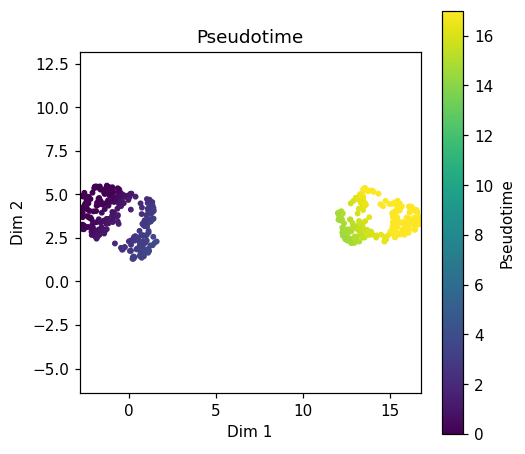

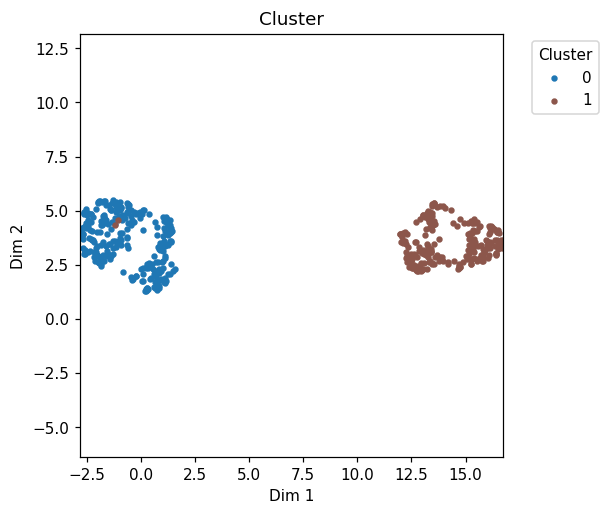

In [12]:
from tic.wrappers import PseudotimeWrapper
ptw = PseudotimeWrapper(rep_key="centre_gene", dr_method="umap", cluster_method="kmeans")
pt_adata = ptw.fit(fw_adata)
ptw.plot(kind="pseudotime")
ptw.plot(kind="cluster")




In [ ]:
import os

from tic.constant import DEFAULT_DATACACHE_DIR

USER_HOME = os.path.expanduser("~")
DATASETS = {
    # "upmc": {
    #     "data_dir": os.path.join(DEFAULT_DATACACHE_DIR, "codex_upmc"),
    #     "out_dir": os.path.join(USER_HOME, "Expriments", "Codex", "upmc")
    # },
    "charville": {
        "data_dir": os.path.join(DEFAULT_DATACACHE_DIR, "codex_charville"),
        "out_dir": os.path.join(USER_HOME, "Expriments", "Codex", "charville")
    },
    "dfci": {
        "data_dir": os.path.join(DEFAULT_DATACACHE_DIR, "codex_dfci"),
        "out_dir": os.path.join(USER_HOME, "Expriments", "Codex", "dfci")
    }
}
print(DATASETS)



In [6]:
import os

def get_region_ids(dir_path):
    """Get all region IDs based on JSON files in the directory."""
    region_ids = []
    for file in os.listdir(dir_path):
        if file.endswith(".cell_data.csv"):
            region_ids.append(file.split(".")[0])
    return sorted(region_ids)

In [7]:
from typing import List

from tqdm import tqdm

from tic.data.loader import load_codex_upmc
from tic.plotting.pseudotime import plot_biomarker_trends
from tic.wrappers.feature import FeatureWrapper
from utils.dataset.codex_upmc import UPMC_EMT_GENES


def single_sample_analysis(data_dir:str, region_ids:List[str], out_dir:str):
    '''
    For each region, extract features and perform single sample analysis and save the results:
    1. pseudotime vs biomarker trends
    2. metrics
    '''
    for region_id in tqdm(region_ids):
        # set up output dir for this region:
        out_prefix = out_dir + f"/{region_id}"
        # load data
        adata = load_codex_upmc(data_dir, region_id=region_id)

        # extract features
        fw = FeatureWrapper(
            recipe="tme_default",
            centre_types=["Tumor"],
            graph_params={"method": "voronoi"},
            subgraph_params={"strategy": "radius", "radius": 75},
        )
        fea_adata = fw.fit(adata)
        from tic.wrappers.pseudotime import PseudotimeWrapper

        methods = ['centre_gene', 'composition', 'neighbor_gene_sum', 'same_type_gene_sum', 'same_type_gene_average']

        for method in methods:
            method_out_prefix = out_prefix + f"/{method}"
            ptw = PseudotimeWrapper(
                rep_key = method,
                output_dir=method_out_prefix,
            )
            pt_adata = ptw.fit(fea_adata)
            plot_biomarker_trends(
                adata = pt_adata,
                selected_biomarkers = UPMC_EMT_GENES,
                x_transform = "bin+normalize",
                y_transform = "normalize",
                bins = 100,
                save_path = method_out_prefix + f"/biomarker_trends.png",
            )
            metrics = ptw.metrics
            metrics.to_csv(method_out_prefix + f"/metrics.csv", index=False)

In [ ]:
for dataset in DATASETS:
    data_dir = DATASETS[dataset]["data_dir"]
    region_ids = get_region_ids(data_dir)
    out_dir = DATASETS[dataset]["out_dir"]
    print(data_dir, region_ids, out_dir)
    os.makedirs(out_dir, exist_ok=True)
    single_sample_analysis(data_dir, region_ids, out_dir)